Computer Vision

We build tools to solve the problem of binocular vision by working backwards through the videos of Shree Nayar from video 5 on Simple Stereo https://www.youtube.com/watch?v=hUVyDabn1Mg&list=PL2zRqk16wsdoCCLpou-dGo7QQNks1Ppzo&index=5


We begin with our calibration cube, and solve its correspondence problem [matching image points [pixel pairs] to known 3d coordinates]


\begin{equation}\label{eq:world2pix}
  \begin{bmatrix} u^{(n)} \\ v^{(n)} \\ 1 \end{bmatrix} = \begin{bmatrix} p[0,0] & p[0,1] & p[0,2] & p[0,3] \\
                                                        p[1,0] & p[1,1] & p[1,2] & p[1,3] \\
                                                        p[2,0] & p[2,1] & p[2,2] & p[2,3] \end{bmatrix}
                                       \begin{bmatrix} x^{(n)} \\ y^{(n)} \\ z^{(n)} \\ 1 \end{bmatrix}           
\end{equation}

that is

\begin{equation}\label{eq:uvp}
  \eqalign{u^{(n)} &= \frac{p[0,0]x^{(n)} + p[0,1]y^{(n)} + p[0,2]z^{(n)} + p[0,3]}
                           {p[2,0]x^{(n)} + p[2,1]y^{(n)} + p[2,2]z^{(n)} + p[2,3]} \cr
           v^{(n)} &= \frac{p[1,0]x^{(n)} + p[1,1]y^{(n)} + p[1,2]z^{(n)} + p[1,3]}
                           {p[2,0]x^{(n)} + p[2,1]y^{(n)} + p[2,2]z^{(n)} + p[2,3]} \cr}
\end{equation}

that is

\begin{equation}\label{eq:uvp12}
\begin{bmatrix} x^{(n)} & y^{(n)} & z^{(n)} & 1 & 0 & 0 & 0 & 0 & -x^{(n)}u^{(n)} & -y^{(n)}u^{(n)} & -z^{(n)}u^{(n)} & -   u^{(n)} \\
  0 & 0 & 0 & 0 &  x^{(n)} & y^{(n)} & z^{(n)} & 1 & -x^{(n)}v^{(n)} & -y^{(n)}v^{(n)} & -z^{(n)}v^{(n)} & -v^{(n)} \end{bmatrix}
  \begin{bmatrix} p[0,0] \\ p[0,1] \\ p[0,2] \\ p[0,3] \\
                  p[1,0] \\ p[1,1] \\ p[1,2] \\ p[1,3] \\
                  p[2,0] \\ p[2,1] \\ p[2,2] \\ p[2,3] \end{bmatrix}
   = \begin{bmatrix} 0 \\ 0 \end{bmatrix}
\end{equation}

We stack these 27 pairs of equations to arrive at one 54x12 system $Ap=0$ subject to $\|p\|=1$, i.e., $p$ is the eigenvector associated with the least eigenvalue of $A^TA$.

In [3]:
# Calibration Cube   img = plt.imread('../Images/CalCube.jpg')
# used    conda install opencv      from terminal "here"
# Shree Nayar     https://www.youtube.com/watch?v=hUVyDabn1Mg&list=PL2zRqk16wsdoCCLpou-dGo7QQNks1Ppzo&index=5

import cv2
import numpy as np
import matplotlib.pyplot as plt

xpix = np.zeros(27)
ypix = np.zeros(27)
ind = 0

def get_coordinates(event, x, y, flags, param):    # Mouse callback function
    global ind
    if event == cv2.EVENT_LBUTTONDOWN:
        xpix[ind] = x
        ypix[ind] = y
        cv2.putText(imgC, str(ind), (x, y), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
        ind = ind + 1
        cv2.imshow('image', imgC)

img = cv2.imread('../Images/CalCube.jpg', 0)  # read in grayscale
#img = img_bgr # cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
(m,n) = img.shape
imgC = cv2.resize(img, None, fx = 0.125, fy=0.125)   # downsample

# Create a window and bind the function to it
cv2.namedWindow('image')
cv2.setMouseCallback('image', get_coordinates)

# Main loop to display the image
print('Click on 9 crossings in the (x,z) plane from low to high')
print('then the 9 crossings in the (y,z) plane')
print('then the 9 crossings in the z = 4 plane')
print("Press 'Esc' to exit.")

while True:
    cv2.imshow('image', imgC)
    k = cv2.waitKey(1) & 0xFF
    if k == 27: # 27 is ASCII for the Esc key
        break
        
print(xpix, ypix)

np.savez('xpixANDypix.npz', first=xpix, second=ypix)
        
cv2.destroyAllWindows()

Click on 9 crossings in the (x,z) plane from low to high
then the 9 crossings in the (y,z) plane
then the 9 crossings in the z = 4 plane
Press 'Esc' to exit.
[497. 567. 630. 500. 575. 645. 504. 584. 659. 357. 296. 235. 346. 280.
 217. 340. 266. 199. 421. 510. 593. 343. 430. 511. 269. 353. 437.] [661. 610. 568. 600. 544. 493. 522. 463. 417. 665. 607. 558. 596. 537.
 485. 525. 462. 409. 374. 318. 272. 317. 271. 225. 271. 229. 192.]


In [30]:
# construct the A matrix then the Projection matrix then partition it

import numpy as np
from numpy import linalg as LA

loaded_data = np.load('xpixANDypix.npz')
u = loaded_data['first']   
v = loaded_data['second'] 

#u = xpix
#v = ypix

x = np.array([1, 2, 3, 1, 2, 3, 1, 2, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 3, 1, 2, 3, 1, 2, 3])
y = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 1, 1, 2, 2, 2, 3, 3, 3])
z = np.array([1, 1, 1, 2, 2, 2, 3, 3, 3, 1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4])

A = np.zeros((54,12))

for n in range(27):
    A[2*n,:] = [ x[n], y[n], z[n], 1, 0, 0, 0, 0, -x[n]*u[n], -y[n]*u[n], -z[n]*u[n], -u[n]]
    A[2*n+1,:] = [ 0, 0, 0, 0,  x[n], y[n], z[n], 1, -x[n]*v[n], -y[n]*v[n], -z[n]*v[n], -v[n]]

#print("A = ", A)
evals, evecs = LA.eigh(A.T@A)  # hermitian solver

print("evals = ",evals)

p = evecs[:,0]   # eigenvector of smallest eigenvalue

print("p = ", p)

P = np.reshape(p, (3,4))
print("P = ", P)

# apply P to [x,y,z] and compare to measured u and v (validation?)

unew = np.zeros(27)
vnew = np.zeros(27)

for n in range(27):
    w = np.array([x[n], y[n], z[n], 1])
    unew[n] = np.dot(P[0,:],w) / np.dot(P[2,:],w)
    vnew[n] = np.dot(P[1,:],w) / np.dot(P[2,:],w)

print("unew = ", unew)
print("u = ", u)

print("vnew = ", vnew)
print("v = ", v)

# now factor

evals =  [2.37671845e-04 8.29565779e-01 1.47463306e+00 2.29045563e+00
 1.15343539e+01 1.64080798e+01 5.77851928e+01 3.47105761e+02
 1.61487687e+06 5.02129757e+06 2.03153088e+07 1.24916103e+08]
p =  [ 9.64002721e-02 -5.43651039e-02 -3.78902423e-02  4.74885343e-01
 -3.16145381e-02 -3.21211343e-02 -1.19465905e-01  8.62841271e-01
  3.95557793e-05  4.29725350e-05 -8.30762451e-05  1.11582902e-03]
P =  [[ 9.64002721e-02 -5.43651039e-02 -3.78902423e-02  4.74885343e-01]
 [-3.16145381e-02 -3.21211343e-02 -1.19465905e-01  8.62841271e-01]
 [ 3.95557793e-05  4.29725350e-05 -8.30762451e-05  1.11582902e-03]]
unew =  [497.4271339  566.43209385 630.6958739  500.8986503  575.34239252
 644.27352721 505.00670285 585.81814509 660.14087404 355.69488975
 293.4348121  235.78098662 347.29267922 280.3868225  218.81219123
 337.35562931 265.06287202 199.01129445 421.86772972 509.88920603
 590.5431601  342.11872595 429.47819006 509.84353575 269.56935687
 356.03697696 435.87039225]
u =  [497. 567. 630. 500. 575. 64

Now we recall that

\begin{equation}\label{eq:Pdec}
  P = M_{int}M_{ext} \hskip 0.25in 
   M_{int} = \begin{bmatrix} R & 0 \end{bmatrix},  \hskip 0.25in
   M_{ext} = \begin{bmatrix} Q & t \\ 0 & 1 \end{bmatrix} \hskip 0.25in
   R = \begin{bmatrix} f_x & 0 & o_x\\ 0 & f_y & o_y\\ 0 & 0 & 1 \end{bmatrix}
\end{equation}

from which we deduce

\begin{equation}\label{eq:Pdec1}
  P[:,0:2] = RQ
\end{equation}

produces $R$ and $Q$ through our RQ decompostion. The remaining column of $P$ then determines $t$ via

\begin{equation}\label{eq:Pdec2}
  P[:,3] = Rt
\end{equation}




In [31]:
import numpy as np

def rot(ind, ang):   # build a rotation matrix from axis index (0,1, or 2 for x,y, or z) and angle
    a = np.zeros(3)
    a[ind] = 1
    aO = np.outer(a, a)
    aX = np.array([[0, -a[2], a[1]], [a[2], 0, -a[0]], [-a[1], a[0], 0]])
    K = aO + np.sin(ang)*aX + np.cos(ang)*(np.eye(3)-aO)
    return K

A = P[:,0:3]
if (np.linalg.det(A) < 0):
    A = -A
print("A = ", A)
print(" ")

alpha = np.arctan(-A[2,1]/A[2,2])   # find alpha
Kx = rot(0,alpha)
B = A@Kx

beta = np.arctan(A[2,0]/B[2,2])   # find beta
Ky = rot(1,beta)
C = B@Ky
if (C[2,2] < 0):                  # ensure that C[2,2] > 0
    Ky = rot(1,beta+np.pi)
    C = B@Ky

gamma = np.arctan(-C[1,0]/B[1,1])   # find gamma
Kz = rot(2,gamma)
R = C@Kz
if (R[1,1] < 0):                  # ensure that R[1,1] > 0
    Kz = rot(2,gamma+np.pi)
    R = C@Kz

print("R = ", R)                 # display the factors
print(" ")
Q = Kz.T@Ky.T@Kx.T
print("Q = ", Q)
print(" ")

print("||A-RQ|| = ", np.linalg.norm(A-R@Q))  # display the distance from A to RQ
print(" ")

t = np.linalg.solve(R, P[:,3])

print("t = ", t)

A =  [[ 9.64002721e-02 -5.43651039e-02 -3.78902423e-02]
 [-3.16145381e-02 -3.21211343e-02 -1.19465905e-01]
 [ 3.95557793e-05  4.29725350e-05 -8.30762451e-05]]
 
R =  [[ 1.07750291e-01 -4.32741675e-04  4.55404766e-02]
 [ 1.38777878e-17  1.05568348e-01  7.18239004e-02]
 [ 4.07440077e-21 -3.16019080e-21  1.01552750e-04]]
 
Q =  [[ 0.72777106 -0.68577105 -0.00820654]
 [-0.56447452 -0.59216389 -0.57507429]
 [ 0.38950968  0.42315482 -0.81806003]]
 
||A-RQ|| =  3.024593730708204e-17
 
t =  [-0.23384477  0.69777829 10.98767911]


gAc.shape =  (1152, 864)
top left of match =  (300, 500)


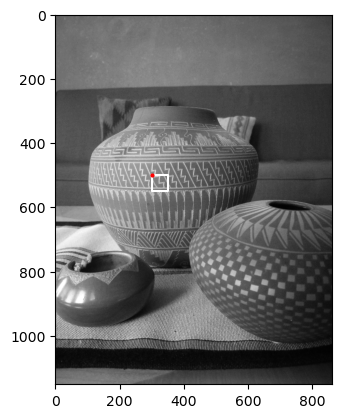

In [30]:
# template match test

import cv2
import numpy as np
import matplotlib.pyplot as plt

gA = cv2.imread('../Images/deptha.jpg', 0)       # the image, gray scale
gAc = cv2.resize(gA, None, fx = 0.25, fy = 0.25)   # reduced
(M,N) = gAc.shape 
print("gAc.shape = ", (M, N))

template = gAc[500:550,300:350]  # the template

result = cv2.matchTemplate(gAc, template, cv2.TM_CCOEFF_NORMED)    # perform match
minVal, maxVal, minLoc, maxLoc = cv2.minMaxLoc(result)      # record results
print("top left of match = ", maxLoc)   # coordinates of top left of match

plt.imshow(gAc, cmap='gray')   # display image
plt.plot([300, 350, 350, 300, 300], [500, 500, 550, 550, 500], 'w') # draw white rectangle around template
plt.plot(maxLoc[0], maxLoc[1], 'ro', markersize=2);  # red circle at to left left of match

gBc.shape =  576 432


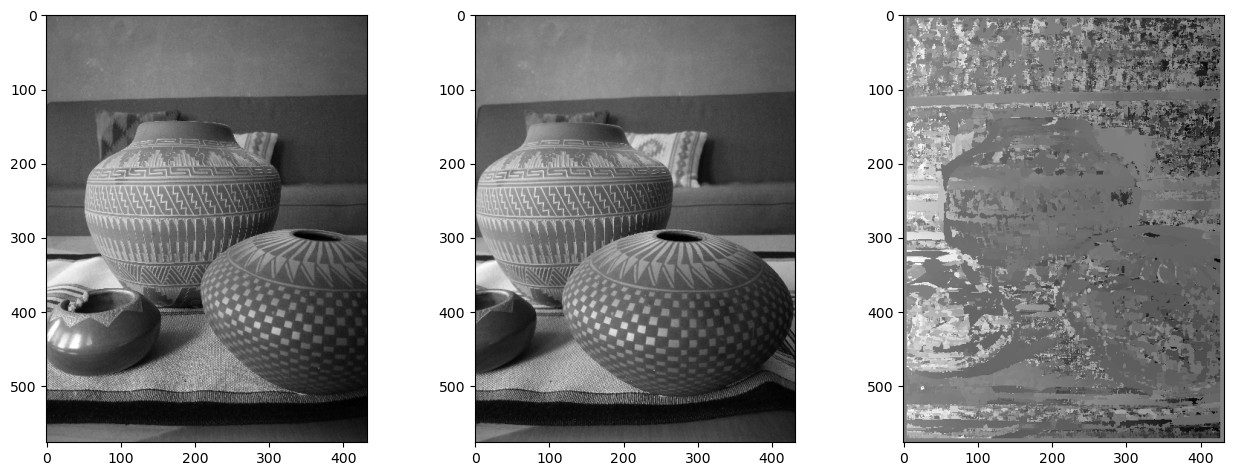

In [40]:
# find correspondences in depth images WITH cv2

import cv2
import numpy as np
import matplotlib.pyplot as plt

fig, (ax1, ax2, ax3) = plt.subplots(1, 3)    # create a figure with 2 axes (plot windows)
plt.subplots_adjust(right=2, top=1, wspace=0.25)  # adjust them for the right look

gA = cv2.imread('../Images/deptha.jpg', 0) 
gAc = cv2.resize(gA, None, fx = 0.125, fy = 0.125)
ax1.imshow(gAc, cmap='gray')

gB = cv2.imread('../Images/depthb.jpg', 0)  
gBc = cv2.resize(gB, None, fx = 0.125, fy = 0.125) 
ax2.imshow(gBc, cmap='gray')
(M,N) = gBc.shape 
print("gBc.shape = ", M, N)

dAB = np.zeros((M,N))

h = 5  # window halfwidth
for m in range(h,M-h):
    wB = gBc[m-h:m+h+1,:]  # the image
    for n in range(h,N-h):
        template = gAc[m-h:m+h+1,n-h:n+h+1]  # the template
        #ax1.plot([n-h,n+h,n+h,n-h,n-h],[m-h,m-h,m+h,m+h,m-h],'w')
        result = cv2.matchTemplate(wB, template, cv2.TM_CCOEFF_NORMED)
        minVal, maxVal, minLoc, maxLoc = cv2.minMaxLoc(result)
        #ax2.plot(maxLoc[0],maxLoc[1]+m,'ro')
        dAB[m,n] = maxLoc[0] - n
        
ax3.imshow(dAB, cmap = 'gray')
    